<a href="https://colab.research.google.com/github/Abhisar-else/Abhisar-else/blob/main/abhisar_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👇 UPLOAD YOUR FILE HERE 👇
Click the 'Choose Files' button that appears below this cell and select your CSV file.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving spam_ham_dataset.csv to spam_ham_dataset (2).csv

Dataset Shape: (5171, 4)
Balanced Dataset Shape: (2998, 4)


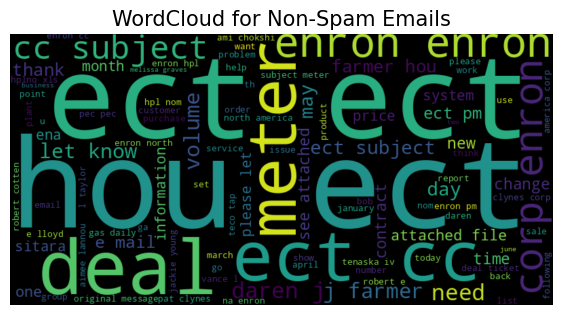

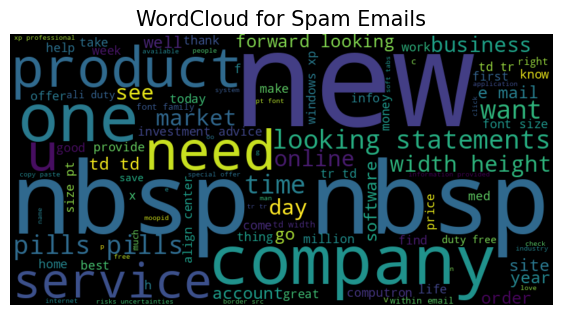


Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5509 - loss: 0.6766 - val_accuracy: 0.6283 - val_loss: 0.6160 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.8403 - loss: 0.3944 - val_accuracy: 0.9450 - val_loss: 0.2237 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9450 - loss: 0.2142 - val_accuracy: 0.9467 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.8745 - loss: 0.3597 - val_accuracy: 0.9400 - val_loss: 0.2708 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9399 - loss: 0.2291 - val_accuracy: 0.9383 - val_loss: 0.2285 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9462 - loss: 0.2099 - val_accuracy: 0.9367 - val_loss: 0.2331 - learning_rate: 5.0000e-04
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9467 - loss: 0.2205

Test Loss : 0.2

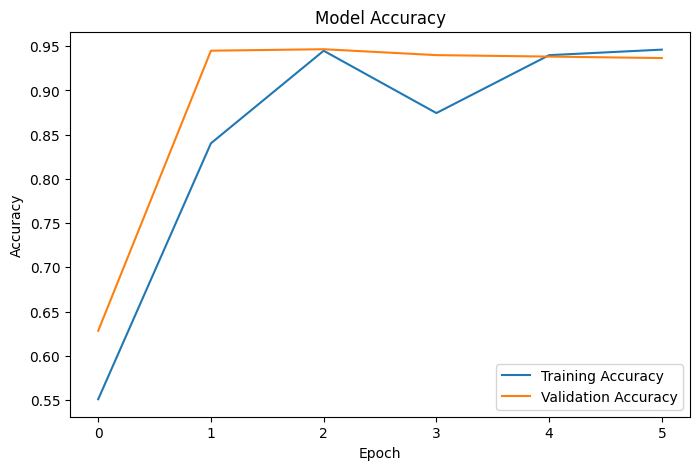

In [18]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings

warnings.filterwarnings('ignore')
nltk.download('stopwords')
#  Upload and Load Dataset
from google.colab import files
print("Click the 'Choose Files' button that appears below this cell and select your CSV file.")
uploaded = files.upload()

# Automatically grab the exact name of the file you just uploaded
filename = list(uploaded.keys())[0]

# Load the dataset directly from Colab's memory
data = pd.read_csv(filename)
print("\nDataset Shape:", data.shape)
# CELL 3: Balance the Dataset
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)
print("Balanced Dataset Shape:", balanced_data.shape)

# Clean the Text
# Remove 'Subject'
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')

# Remove Punctuations
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)

balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punctuations(x))

# Remove Stopwords
stop_words = stopwords.words('english')
def remove_stopwords(text):
    imp_words = [word.lower() for word in str(text).split() if word.lower() not in stop_words]
    return " ".join(imp_words)

balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))

# Visualize Word Clouds
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

#  Tokenization and Padding

# Split the data
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42)

# Tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)
train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

# Pad
max_len = 100
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

# Convert labels to binary (1 for Spam, 0 for Ham)
train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

#  Define the Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam',
    metrics=['accuracy']
)

print("\nModel Summary:")
model.summary()


#  Train the Model
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)
#  Evaluate and Plot
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('\nTest Loss :', test_loss)
print('Test Accuracy :', test_accuracy)

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### Custom Model Testing
Use the cell below to verify if a specific email is flagged as Spam or Ham by your trained model.

In [ ]:
def predict_email(user_input):
    # Preprocess the input string
    cleaned_text = user_input.replace('Subject', '')
    cleaned_text = remove_punctuations(cleaned_text)
    cleaned_text = remove_stopwords(cleaned_text)

    # Tokenize and Pad
    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded_seq = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Predict
    prediction = model.predict(padded_seq, verbose=0)

    if prediction[0][0] > 0.5:
        return f"Spam (Confidence: {prediction[0][0]:.2%})"
    else:
        return f"Ham (Confidence: {1 - prediction[0][0]:.2%})"

# --- TEST IT HERE ---
my_email = "Congratulations! You have won a $1000 gift card. Click here to claim your prize now!"
result = predict_email(my_email)

print(f"Email Content: {my_email}")
print(f"Result: {result}")